### The code imports necessary packages: 

**NumPy** is a package for scientific computing with arrays.

**matplotlib** is a package for creating visualizations.

**random** is a built-in package that can be used to generate random numbers.

**pandas** is a package for data manipulation and analysis.

**pickle** is a serialization and deserialization module that can be used to store and retrieve Python objects.

**time** is a built-in package that provides functions to work with time.

**warnings** is a built-in package that can be used to suppress warnings in the code.

### Defining functions that will be used later.

Each function takes an input


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from numpy.random import seed
from numpy.random import normal
import pandas as pd
import pickle
import time
import warnings
import itertools
from typing import Dict
import math
import datetime
import statistics
# Turn off FutureWarning
warnings.filterwarnings("ignore")


##Interaction matrix of residents and mutants species with x trait values 
def A_res_mut(x_trait,sigma):
    diff = np.subtract.outer(x_trait, x_trait)
    #diff2 =np.subtract.outer(y_trait, y_trait)
    result = np.exp(-np.power(diff,2 )/(2*sigma**2))
    return result

#Resource competition
def r_kennel(x_trait,sigmar):
    growth = []
    for x in x_trait[0::]:
        growth.append(np.maximum(np.exp(-np.power((x),2)/(2*sigmar**2))-0.0002, 0))
    return np.array(growth)

#Variance and Expectation

def off_diag_expect_var(matrix):
    # Extract the off-diagonal entries of the matrix
    n = matrix.shape[0]
    off_diag_entries = []
    
    for i in range(n):
        for j in range(i+1, n):
            off_diag_entries.append(matrix[i][j])
    
    var_x = np.var(off_diag_entries)
    mean = np.mean(off_diag_entries)
    
    return mean, var_x


def jaccard_similarity(d: Dict[int, list], step_size: int = 5, num_keys: int = 10) -> Dict:
    result = {}
    keys = list(d.keys())[-num_keys:]
    for i in keys:
        for j in keys:
            if abs(i - j) == step_size:
                set_i = set(d[i])
                set_j = set(d[j])
                intersection = len(set_i.intersection(set_j))
                union = len(set_i.union(set_j))
                if union != 0:
                    result[(i, j)] = intersection / union
                else:
                    result[(i, j)]=0
    return result

def hill_number(abundances, q):
    p = abundances / abundances.sum()
    if q == 0:
        return len(p)
    else:
        return np.power(np.sum(np.power(p, q)), -1 / (q - 1))
    
    
def Combinations(number):
    
    # Define the possible values for each parameter
     # Generate n random floats between 0 and 1 without repeats
    param1= random.sample([random.uniform(0.5, 1) for i in range(1000)],number)#[round(random.random(),4) for _ in range(10)]
    param2= random.sample([random.uniform(0, 0.5) for i in range(1000)], number)

    # Generate n random integers without repeats
    param3=[random.uniform(0, 5) for _ in range(number)]
    ##print(len(Combinations))

    # Generate all possible combinations of values for the three parameters
    Combinations = list(itertools.product(param1, param2, param3))
    #print(combinations)
    # Print each combination
    #for combination in Combinations:
        #param1, param2, param3 = combination
        #print(f"param1: {param1}, param2: {param2}, param3: {param3}")
        #print(combination)
    return Combinations


def introduction_rate_mean(Dict,n_iterations):
    #print(len(Intro))    
    #print(cp1)
    last_ = list(Dict.values())[-n_iterations:]
    #Intro_mean = sum(last_)/ len(last_)
    Intro_mean = statistics.mean(last_)
    Intro_variance = statistics.variance(last_)
    return Intro_mean, Intro_variance
    

def RAO_(list_1, list_2):
    #RAO
    differences = []
    proportions = []

    sum_list_1 = sum(list_1)
    sum_list_2 = sum(list_2)

    for i in range(len(list_1) - 1):
        for j in range(i+1, len(list_1)):
            diff = list_1[j] - list_1[i]
            differences.append(diff**2)
            proportion_i = list_2[i] / sum_list_2
            proportion_j = list_2[j] / sum_list_2
            proportions.append(proportion_i * proportion_j)

    result = sum([diff * prop for diff, prop in zip(differences, proportions)])
    #RAO[i] = result
    return result

def RAO_mean_(Dict, n_iterations):
    #RAO_mean
    m = list(Dict.values())[-n_iterations:]
    m_mean = statistics.mean(m)
    m_variance = statistics.variance(m)
    return m_mean,m_variance

def functional_turnover(Dict, lag,n_iterations):
    my_dict=Dict
    #Function turnover
    differences = []

    for i, key1 in enumerate(my_dict):
        for j in range(i + lag, len(my_dict)):
            key2 = list(my_dict.keys())[j]
            diff = my_dict[key2] - my_dict[key1]
            differences.append(abs(diff))
    if len(differences[-n_iterations:])!= 0:
        mean= sum(differences[-n_iterations:])/ len(differences[-n_iterations:])
    else:
        mean=0
    #DeltaRAO1[params] = mean
    return mean

def trait_var(Dict,n_iterations):
    t_variances = {}
    for inner_key, inner_value in Dict.items():
        if inner_value:
            mean = sum(inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
            variance = sum((x - mean) ** 2 for x in inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
            t_variances[inner_key] = variance
        else:
            t_variances[inner_key] = 0

    if len(list(t_variances.values())) != 0:
        t_variance = np.var(list(t_variances.values()), ddof=1)
    else:
        t_variance = 0
    #Trait_var[params] = t_variance
    return t_variance

def trait_mean_(Dict,n_iterations):
    t_means = {}
    for inner_key, inner_value in Dict.items():
        if inner_value:
            t_means[inner_key] = sum(inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
        else:
            t_means[inner_key] = 0

    t_mean = sum(list(t_means.values()))/len(list(t_means.values()))
    #trait_mean[params] = t_mean
    return t_mean

def mean_abundances(Dict,n_iterations):
    ssp=[]
    for k,var in Dict.items():
        ssp.append(var)
    #ssp
    # creating dataframe
    row_sum = []
    df = pd.DataFrame(ssp[-n_iterations:])
    df.fillna(0)
    ro_sum = df.sum(axis=1)
    if len(ro_sum) != 0:
        ab_mean= sum(ro_sum)/len(ro_sum)
    else:
        ab_mean = 0
    return ab_mean
def mean_inter_strength(Dict,n_iterations):
    aij_means = {}
    #print(len(aij))
    for inner_key, inner_value in Dict.items():
        #print(inner_key)
        aij_means[inner_key] = off_diag_expect_var(inner_value)[0] 
    #print('ll=',aij_means)
    if len(list(aij_means.values())[-n_iterations:])!=0:
           aij_mean = sum(list(aij_means.values())[-n_iterations:])/len(list(aij_means.values())[-n_iterations:])
    else:
           aij_mean =0
    return aij_mean
def var_inter_str(Dict,n_iterations):
    aij_variances = {}
    for inner_key, inner_value in Dict.items():
        if inner_value.any():
            mean =off_diag_expect_var(inner_value)[0]
            variance = off_diag_expect_var(inner_value)[1]
            aij_variances[inner_key] = variance
        else:
            aij_variances[inner_key] = 0
    #print('varai', aij_variances)
    if len(list(aij_variances.values())[-n_iterations:]) != 0:
        aij_variance = np.mean(list(aij_variances.values())[-n_iterations:])
    else:
        aij_variance = 0
    return aij_variance

def growth_rate_mean(Dict,n_iterations):
    ri_means = {}
    for inner_key, inner_value in Dict.items():
        if inner_value.any():
            ri_means[inner_key] = sum(inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
        else:
            ri_means[inner_key] = 0

    ri_mean = sum(list(ri_means.values()))/len(list(ri_means.values()))
    return ri_mean

def growth_rate_var(Dict,n_iterations):
    ri_variances = {}
    for inner_key, inner_value in Dict.items():
        if inner_value.any():
            mean = sum(inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
            variance = sum((x - mean) ** 2 for x in inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
            ri_variances[inner_key] = variance
        else:
            ri_variances[inner_key] = 0

    if len(list(ri_variances.values())) != 0:
        ri_variance = np.var(list(ri_variances.values()), ddof=1)
    else:
        ri_variance = 0
    return ri_variance

def Jaccard_mean(Dict, num, last_iterations):
    result = jaccard_similarity(Dict,num,last_iterations)
    merged_dict = {}
    for key, value in result.items():
        if key[::-1] in merged_dict:
            merged_dict[key[::-1]] = (merged_dict[key[::-1]] + value) / 2
        else:
            merged_dict[key] = value

    a = list(merged_dict.values())
    if len(a) != 0:
        j_mean=sum(a)/len(a)
    else:
        j_mean = 0
    return j_mean

import numpy as np

# Define the power iteration function
def power_iteration(A, max_iterations=1000, tolerance=1e-6):
    n = A.shape[0]
    b_k = np.random.rand(n)  # Random initial vector
    for _ in range(max_iterations):
        b_k1 = A @ b_k
        b_k1_norm = np.linalg.norm(b_k1)
        b_k1 /= b_k1_norm
        if np.linalg.norm(b_k1 - b_k) < tolerance:
            break
        b_k = b_k1
    return b_k @ A @ b_k / (b_k @ b_k)

#### Call "combinations" function to generate a combination of parameters

In [2]:
Combinations=Combinations(1)


In [3]:
import collections

counted_list = collections.Counter(Combinations)
#print(counted_list)
print(len(counted_list))


1


In [4]:
with open('Combinations', 'wb') as f:
    pickle.dump(Combinations,f)
with open('Combinations', 'rb') as f:
    Combinations=pickle.load(f)

The code starts by importing the time library and setting a timer. It then initializes dictionaries and variables that will store information about the simulated communities, including richness (**Richness**), Shannon diversity (**Shan**), Simpson diversity (**Simp**), species abundances (**Abund2**), structural stability (**Stab1, Stab2**), current species mean(**Current_sp**), current species variation (**Current_sp_var**), trait variation (**Trait_var**), trait mean (**Trait_mean**), mean interaction strengths (**Aij**), interaction strength variation (**Aij_var**), mean intrinsic growth rates (**Ri**), intrinsic growth rate variation (**Ri_var**), species introduction (**Introd**), Jaccard similarity lagged between time points (**Jaccard_lag1, Jaccard_lag5, etc.**), and RAO index (**RAO_mean**).

The code then sets some initial values for number of species in a closed system (**n**), the number of iterations before introducing new species (**start**), total number of iterations (**N_iter**), and snapshot of last iterations (**n_iterations**). 

The main loop in the code starts iterates through a list of combination of parameters. The code then model a closed system for "start" number of iterations. Next, the loop simulates species richness and abundances for **N_iter - start iterations**, adding new species at rate **"lam"** and using the Poisson model to implement demographic stochasticity. After saving the information for all iterations,then calculate RAO index, and Jaccard similarity lagged between time points.


In [5]:
import time

# start the timer
start_time = time.time()


#overall
Richness = {}
Shan = {}
Shn_1 = {}
Simp = {}
Abund2 ={}
Stab1 ={}
Stab2 = {}
Current_sp = {}
Current_sp_var = {}
Trait_var ={}
trait_mean ={}
Aij ={}
Aij_var={}
Ri ={}
Ri_var={}
Introd={}
Jaccard_lag1={}
Jaccard_lag5={}
Jaccard_lag10={}
Jaccard_lag50={}
Jaccard_lag100={}
Jaccard_lag1000={}
DeltaRAO1={}
DeltaRAO5={}
DeltaRAO10={}
DeltaRAO50={}
DeltaRAO100={}
DeltaRAO1000={}
RAO_mean ={}
cp1_={}
intr={}
Eigen_mean={}
Eigen_var={}
n,start,N_iter,n_iterations =100, 200, 1800, 1000
J=100
for combination in Combinations:
     #species abundances
    sp_dict={}
    
    # structural stability limity
    sp_limit=[]
    sp_limit1=[]
    sp_limit2=[]
    sp_limit3=[]
    sp_limit4=[]
    sp_limit5=[]
    sp_limit6=[]
    
    #species richness
    cp1={}
    #species traits
    trait={}
    # list of species abundaces
    sp1=[]
    # sigmar 
    aij = {}
    #sigmar.append()
    ri = {}
    Intro = {}
    RAO = {}
    #initial number of species  
    eig =[]
    H0 = []
    H1=[]
    H2 = []
    #nj = list(np.random.randint(5,20,200))
    current_species=list(np.arange(0,n,1))
    #print('current_species',len(current_species))
    old_n = list(np.random.uniform(0.01,0.2,n))
    #print('old_n',len(old_n))
    xi=np.random.uniform(-1,1,n) # x trait value
    current_xi =[var for j,var in enumerate(xi) if j in current_species]
    #print('current_s',len(nJ))
    sigmar=combination[0]
    sigma = combination[1]
    lam = combination[2]
    for i in range(0,start):
        if i==0:
            im=np.full((len(current_species),),0.01)
            cp1[i]=current_species
            trait[i]=current_xi
            aij[i]= A_res_mut(current_xi,sigma)
            ri[i]= r_kennel(current_xi,sigmar)
            Intro[i] = 0
            sp1.append(list(old_n))
            d = dict(zip(current_species,old_n))
            sp_dict[i] = d
            # Function for calculating expectation
            expect = off_diag_expect_var(A_res_mut(current_xi,sigma))[0]
            var = off_diag_expect_var(A_res_mut(current_xi,sigma))[1]
            #s_starv1 = np.exp(num)*(1-expect)**2/(2*var)
            s_starv2 = (1-expect)**2/(2*var)
            #sp_limit.append(s_starv1)
            sp_limit1.append(s_starv2)
            #RAO
            RAO[i] = RAO_(current_xi, old_n)

            #print(np.array(new_n))
            # Calculate Hill numbers for q = 0, 1, and 2
            h0 = hill_number(np.array(old_n), 0)
            h1 = hill_number(np.array(old_n), 1.001)
            h2 = hill_number(np.array(old_n), 2)

            H0.append(h0)
            H1.append(h1)
            H2.append(h2)
            
            
            if len(list(A_res_mut(current_xi, sigma))) != 0:
                # Calculate the eigenvalue using power iteration method
                max_eigenvalue_iteration = power_iteration(A_res_mut(current_xi, sigma))

                # Store the real part of the maximum eigenvalue
                max_eigenvalue_iteration_real = max_eigenvalue_iteration.real

                eig.append(max_eigenvalue_iteration_real)

            else:
                eig.append(0)
        else:
            #print(old_n)
            #print('l',r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n)
            #print('e',np.exp(r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n))
            lambdas= J*(old_n*np.exp(r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n))
            #print('lam',lambdas)
            new_n= np.random.poisson(lambdas, len(current_species))/J
            #print(new_n)
            #print('d',d)
            cp1[i]=current_species
            trait[i]=current_xi
            aij[i]= A_res_mut(current_xi,sigma)
            ri[i]= r_kennel(current_xi,sigmar)
            Intro[i] = 0
            sp1.append(list(new_n))
            d = dict(zip(current_species,new_n))
            sp_dict[i] = d
            remove=np.array(np.where(new_n==0))
            #print(type(remove))
            keep=np.where(new_n>0)
            current_spec=[int(e) for i,e in enumerate(current_species) if i not in remove]
            #print(current_spec)
            current_species= list(np.array(current_species)[keep])
            #print('current_species',current_species)
            new_n = list(np.array(new_n)[keep])
            #print('new_n',len(new_n))
            current_xi=[var for j,var in enumerate(current_xi) if j not in remove]
            #nJ=[var for j,var in enumerate(nJ) if j not in remove]
            #print('current_xtrait',len(current_xtrait))
            old_n = list(new_n) 

            # Function for calculating expectation
            expect = off_diag_expect_var(A_res_mut(current_xi,sigma))[0]
            var = off_diag_expect_var(A_res_mut(current_xi,sigma))[1]
            #s_starv1 = np.exp(num)*(1-expect)**2/(2*var)
            s_starv2 = (1-expect)**2/(var)
            #sp_limit.append(s_starv1)
            sp_limit1.append(s_starv2)

            #RAO
            RAO[i] = RAO_(current_xi, new_n)

            #print(np.array(new_n))
            # Calculate Hill numbers for q = 0, 1, and 2
            h0 = hill_number(np.array(new_n), 0)
            h1 = hill_number(np.array(new_n), 1.001)
            h2 = hill_number(np.array(new_n), 2)

            H0.append(h0)
            H1.append(h1)
            H2.append(h2)
        
            if len(list(A_res_mut(current_xi, sigma))) != 0:
                # Calculate the eigenvalue using power iteration method
                max_eigenvalue_iteration = power_iteration(A_res_mut(current_xi, sigma))

                # Store the real part of the maximum eigenvalue
                max_eigenvalue_iteration_real = max_eigenvalue_iteration.real

                eig.append(max_eigenvalue_iteration_real)

            else:
                eig.append(0)           

    for i in range(start,N_iter):
        #print(old_n)
        #print('l',r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n)
        #print('e',np.exp(r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n))
        lambdas= J*(old_n*np.exp(r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n))
        #print(lambdas)
        new_n=  np.random.poisson(lambdas, len(current_species))/J
        #print(new_n)
        #adding new species
        num=np.random.poisson(lam, size=None)
        #print(num)
        new_n= list(new_n) + list(np.full((num,),0.001))
        current_species= current_species + random.sample(range(10000,40000),num)
        #print('current_species',len(current_species))
        current_xi=current_xi+list(np.random.uniform(-10,10,num))
        #print('current_xi',len(current_xi))
        d = dict(zip(current_species,new_n))
        sp_dict[i] = d
        cp1[i]=current_species
        trait[i]=current_xi
        aij[i]= A_res_mut(current_xi,sigma)
        ri[i]= r_kennel(current_xi,sigmar)
        Intro[i] = num
        sp1.append(list(new_n))
        remove=np.array(np.where(np.array(new_n)==0))
        #print(remove)
        keep=np.where(np.array(new_n)>0)
        #print(keep)
        current_species=[int(e) for i,e in enumerate(current_species) if i not in remove]
        #print(current_spec)
        #current_spec= list(np.array(current_spec)[keep])

        new_n = list(np.array(new_n)[keep])
        #print('new_n',len(new_n))
        current_xi=[var for j,var in enumerate(current_xi) if j not in remove]
        #print('current_xtrait',(len(current_xi)))
        #nJ =[var for j,var in enumerate(nJ) if j not in remove]

        old_n =  list(new_n) #list(new_n) + list(np.full((num,),60) )#random.sample(range(0,80),num)
        #print(len(old_n))
        #current_species= current_species + random.sample(range(10000,40000),num)
        #current_xi=current_xi+list(np.random.uniform(-1,1,num))


        # Function for calculating expectation
        mean = off_diag_expect_var(A_res_mut(current_xi,sigma))[0]
        #print('m=',mean)
        var = off_diag_expect_var(A_res_mut(current_xi,sigma))[1]
        #print('v=',var)
        s_starv1 = np.exp(num)*(1-mean)**2/(2*var)
        #print('s1=', s_starv1)
        s_starv2 = (1-mean)**2/(2*var)
        
        s_starv3 = num*(1-mean)**2/(2*var)
        
        s_starv4 = np.mean(r_kennel(current_xi,sigmar))*num*(1-mean)**2/(2*var)
        
        s_starv5 = (np.mean(r_kennel(current_xi,sigmar))*num*(1-mean)**2/(2*var))**0.5
        s_starv6 = (np.mean(r_kennel(current_xi,sigmar))*num*(1-mean)**2/(var))**0.5
        s_starv7 = (1-mean)**2/(var)
        #print('s2=', s_starv2)
        sp_limit.append(s_starv1)
        sp_limit1.append(s_starv2)
        sp_limit2.append(s_starv3)
        sp_limit3.append(s_starv4)
        sp_limit4.append(s_starv5)
        sp_limit5.append(s_starv6)
        sp_limit6.append(s_starv7)

        #RAO
        RAO[i] = RAO_(current_xi, new_n)

        # Calculate Hill numbers for q = 0, 1, and 2
        h0 = hill_number(np.array(new_n), 0)
        h1 = hill_number(np.array(new_n), 1.001)
        h2 = hill_number(np.array(new_n), 2)
        H0.append(h0)
        H1.append(h1)
        H2.append(h2)
        
        if len(list(A_res_mut(current_xi, sigma))) != 0:
            # Calculate the eigenvalue using power iteration method
            max_eigenvalue_iteration = power_iteration(A_res_mut(current_xi, sigma))

            # Store the real part of the maximum eigenvalue
            max_eigenvalue_iteration_real = max_eigenvalue_iteration.real

            eig.append(max_eigenvalue_iteration_real)

        else:
            eig.append(0)           

    #print(len(Intro))    
    #Introduction rate
    #overall
    #Richness = {}
    Shan = {}
    Shn_1 = {}
    Simp = {}
    Abund2 ={}
    Stab1 ={}
    Stab1_var ={}
    Stab2 = {}
    Stab2_var = {}
    Stab3 = {}
    Stab3_var = {}
    Stab4 = {}
    Stab4_var = {}
    Stab5 = {}
    Stab6 = {}
    Stab7 = {}
    Stab5_var = {}
    Current_sp = {}
    Current_sp_var = {}
    Trait_var = {}
    trait_mean = {}
    Aij = {}
    Aij_var = {}
    Ri = {}
    Ri_var = {}
    Introd = {}
    Introd_var ={}
    Jaccard_lag1={}
    Jaccard_lag5={}
    Jaccard_lag10={}
    Jaccard_lag50={}
    Jaccard_lag100={}
    Jaccard_lag200={}
    DeltaRAO1={}
    DeltaRAO5={}
    DeltaRAO10={}
    DeltaRAO50={}
    DeltaRAO100={}
    DeltaRAO200={}
    RAO_mean ={}
    RAO_var ={}
    Eigen_mean={}
    Eigen_var={}
    ##_________________________________________________________________
    Introd[combination] = introduction_rate_mean(Intro,n_iterations)[0]
    Introd_var[combination] = introduction_rate_mean(Intro,n_iterations)[1]

    #RAO_mean
    RAO_mean[combination]= RAO_mean_(RAO,n_iterations)[0]
    RAO_var[combination]= RAO_mean_(RAO,n_iterations)[1]
    #Function turnover
    DeltaRAO1[combination] = functional_turnover(RAO, 1,n_iterations)
    DeltaRAO5[combination] = functional_turnover(RAO, 5,n_iterations)
    DeltaRAO10[combination] = functional_turnover(RAO, 10,n_iterations)
    DeltaRAO50[combination] = functional_turnover(RAO, 50,n_iterations)
    DeltaRAO100[combination] = functional_turnover(RAO, 100,n_iterations)
    DeltaRAO200[combination] = functional_turnover(RAO, 200,n_iterations)

    rich_var_count = {inner_key: len(inner_value) for inner_key, inner_value in cp1.items()}
    rich_var_count_values = list(rich_var_count.values())[-n_iterations:]
    rmean = sum(rich_var_count_values) / len(rich_var_count_values) if len(rich_var_count_values) != 0 else 0
    variance = sum((x - rmean) ** 2 for x in rich_var_count_values) / len(rich_var_count_values) if len(rich_var_count_values) != 0 else 0
    Current_sp_var[combination] = variance

    #Richness
    rich_count = {inner_key: len(inner_value) for inner_key, inner_value in cp1.items()}
    last_counts = list(rich_count.values())[-n_iterations:]
    rmean = sum(last_counts) / len(last_counts) if len(last_counts) != 0 else 0
    Current_sp[combination] = rmean

    #Mean Shannon Entropy
    H_shan = [math.log(x) for x in H1]
    sha_mean = sum(H_shan[-n_iterations:]) / len(H_shan[-n_iterations:]) if len(H_shan[-n_iterations:]) != 0 else 0 
    Shan[combination] = sha_mean

    #Mean Simpson Entropy
    Simpson=np.power(H2,-1)
    if len(Simpson[-n_iterations:])!= 0:
        shi_mean = sum(Simpson[-n_iterations:])/len(Simpson[-n_iterations:])
    else:
        shi_mean = 0 
    Simp[combination] =shi_mean
    #___________________________________________________________________________
    #eig_mean = sum(eig[-n_iterations:]) / len(eig[-n_iterations:]) if len(eig[-n_iterations:]) != 0 else 0 
    #Eigen_mean[combination] = eig_mean
    # eigenvalues
    
    if len(sp_limit[-n_iterations:]) != 0:
        eig_mean= statistics.mean(eig[-n_iterations:])
        eig_variance = statistics.variance(eig[-n_iterations:])
    else:
        eig_mean = 0
        eig_variance = 0

    Eigen_mean[combination] = eig_mean
    Eigen_var[combination]=eig_variance
    #____________________________________________________________________
    # S_star with Introduction rate
    
    if len(sp_limit[-n_iterations:]) != 0:
        st1_mean = statistics.mean(sp_limit[-n_iterations:])
        st1_variance = statistics.variance(sp_limit[-n_iterations:])
    else:
        st1_mean = 0
        st1_variance = 0

    Stab1[combination] = st1_mean
    Stab1_var[combination]=st1_variance

    #_____________________________________________________
    if len(sp_limit1[-n_iterations:]) != 0:
        st1_mean = statistics.mean(sp_limit1[-n_iterations:])
        st1_variance = statistics.variance(sp_limit1[-n_iterations:])
    else:
        st1_mean = 0
        st1_variance = 0

    Stab2[combination] = st1_mean
    Stab2_var[combination]=st1_variance
    #______________________________________
    if len(sp_limit2[-n_iterations:]) != 0:
        st1_mean = statistics.mean(sp_limit2[-n_iterations:])
        st1_variance = statistics.variance(sp_limit2[-n_iterations:])
    else:
        st1_mean = 0
        st1_variance = 0

    Stab3[combination] = st1_mean
    Stab3_var[combination]=st1_variance
    #_____________________________________________________
    if len(sp_limit3[-n_iterations:]) != 0:
        st1_mean = statistics.mean(sp_limit3[-n_iterations:])
        st1_variance = statistics.variance(sp_limit3[-n_iterations:])
    else:
        st1_mean = 0
        st1_variance = 0

    Stab4[combination] = st1_mean
    Stab4_var[combination]=st1_variance
    #________________________________________________________________
    
    if len(sp_limit4[-n_iterations:]) != 0:
        st1_mean = statistics.mean(sp_limit4[-n_iterations:])
        st1_variance = statistics.variance(sp_limit4[-n_iterations:])
    else:
        st1_mean = 0
        st1_variance = 0

    Stab5[combination] = st1_mean
    Stab5_var[combination]=st1_variance
    #________________________________________
    if len(sp_limit5[-n_iterations:]) != 0:
        st1_mean = statistics.mean(sp_limit5[-n_iterations:])
        st1_variance = statistics.variance(sp_limit5[-n_iterations:])
    else:
        st1_mean = 0
        st1_variance = 0

    Stab6[combination] = st1_mean
    #Stab5_var[combination]=st1_variance
    #______________________________________________
    if len(sp_limit6[-n_iterations:]) != 0:
        st1_mean = statistics.mean(sp_limit6[-n_iterations:])
        st1_variance = statistics.variance(sp_limit6[-n_iterations:])
    else:
        st1_mean = 0
        st1_variance = 0

    Stab7[combination] = st1_mean
    #Stab5_var[combination]=st1_variance

    #variance of traits
    Trait_var[combination] = trait_var(trait,n_iterations)

    # mean of traits
    trait_mean[combination] = trait_mean_(trait,n_iterations)

    #mean of abundances
    Abund2[combination] = mean_abundances(sp_dict,n_iterations)

    # Calculate the mean of the arrays in each inner dict
    Aij[combination] = mean_inter_strength(aij,n_iterations)

    #variance of interaction strength
    Aij_var[combination] = var_inter_str(aij,n_iterations)

    #Intrinsic growth rate
    Ri[combination] = growth_rate_mean(ri,n_iterations)

    Ri_var[combination] = growth_rate_var(ri,n_iterations)

    #Jaccard_mean
    Jaccard_lag1[combination] = Jaccard_mean(cp1, 1, n_iterations)
    Jaccard_lag5[combination] = Jaccard_mean(cp1, 5, n_iterations)
    Jaccard_lag10[combination] = Jaccard_mean(cp1, 10, n_iterations)
    Jaccard_lag50[combination] = Jaccard_mean(cp1, 50, n_iterations)
    Jaccard_lag100[combination] = Jaccard_mean(cp1, 100, n_iterations)
    Jaccard_lag200[combination] = Jaccard_mean(cp1, 200, n_iterations)
    
with open('f1s', 'wb') as f:
    pickle.dump(cp1_,f)
with open('f2s', 'wb') as f:
    pickle.dump(intr,f)
    
# stop the timer
end_time = time.time()

# calculate the elapsed time
elapsed_time = end_time - start_time

# print the elapsed time in seconds
print("Elapsed time:", elapsed_time, "seconds")
   

Elapsed time: 222.51009106636047 seconds


In [6]:
with open('f1ss', 'wb') as f:
    pickle.dump(cp1_,f)
with open('f2ss', 'wb') as f:
    pickle.dump(intr,f)

In [7]:
with open('f1ss', 'rb') as f:
    sp = pickle.load(f)

In [8]:
richness=[]
for i in cp1.values():
    richness.append(len(i))

In [11]:
#richness

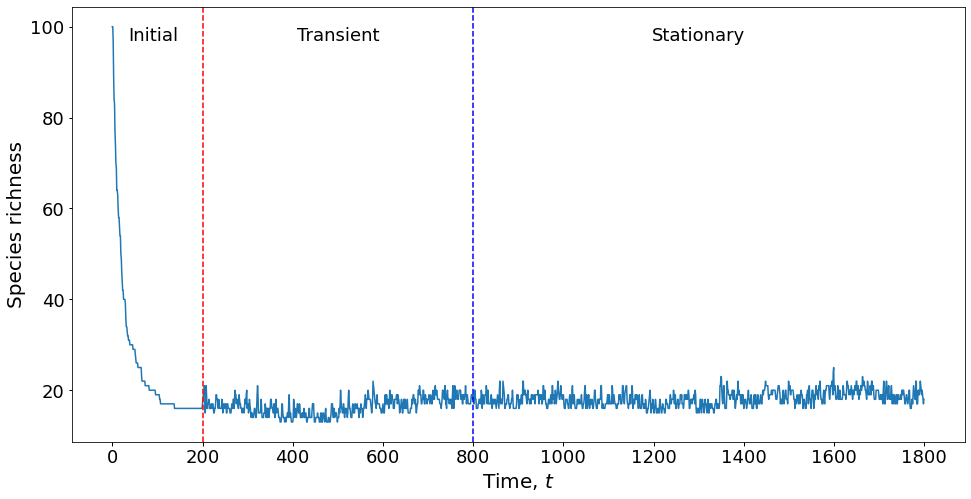

In [12]:
import matplotlib.pyplot as plt

# Assuming you have a DataFrame called fina_df

# Create a figure and axes
fig, ax = plt.subplots(figsize=(16, 8))

# Plot the data from the column
ax.plot(richness)

# Define the positions of vertical lines
initial_line = 200
transient_line = 800
stationary_line = 1800

# Add vertical lines at the specified positions
ax.axvline(x=initial_line, color='red', linestyle='--')
ax.axvline(x=transient_line, color='blue', linestyle='--')
#ax.axvline(x=stationary_line, color='green', linestyle='--')

# Set x-axis ticks
ax.set_xticks(range(0, 1800 + 1, 200))

# Set labels for x-axis and y-axis
ax.set_xlabel('Time, $t$', fontsize=20)
ax.set_ylabel('Species richness', fontsize=20)

# Increase the font size of the tick labels
ax.tick_params(axis='both', labelsize=18)

# Bolden the tick labels
ax.xaxis.set_tick_params(which='both', width=1)
ax.yaxis.set_tick_params(which='both', width=1)

# Add text labels for the ranges
ax.text(90, max(richness), 'Initial', rotation=0, va='top', ha='center', fontsize=18)
ax.text((initial_line + transient_line) / 2, max(richness), 'Transient', rotation=0, va='top', ha='center', fontsize=18)
ax.text((transient_line + stationary_line) / 2,max(richness), 'Stationary', rotation=0, va='top', ha='center', fontsize=18)

# Save the plot as a PNG image
plt.savefig('local_com.png', dpi=900)


In [154]:
len(sp_limit5)

1600

In [5]:
import time

# start the timer
start_time = time.time()
rich = []
mean_rich = []
# Define a list of different J values
J_values = [1000, 3000, 5000,7000,9000,11000,13000,15000,17000,19000]  # Add more values as needed

# Create dictionaries to store results for each J value
#overall
Richness = {}
Shan = {}
Shn_1 = {}
Simp = {}
Abund2 ={}
Stab1 ={}
Stab2 = {}
Current_sp = {}
Current_sp_var = {}
Trait_var ={}
trait_mean ={}
Aij ={}
Aij_var={}
Ri ={}
Ri_var={}
Introd={}
Jaccard_lag1={}
Jaccard_lag5={}
Jaccard_lag10={}
Jaccard_lag50={}
Jaccard_lag100={}
Jaccard_lag1000={}
DeltaRAO1={}
DeltaRAO5={}
DeltaRAO10={}
DeltaRAO50={}
DeltaRAO100={}
DeltaRAO1000={}
RAO_mean ={}
cp1_={}
intr={}
Eigen_mean={}
Eigen_var={}
n,start,N_iter,n_iterations =100, 200, 1800, 1000


# Loop through different J values
for J in J_values:
    for combination in Combinations:
         #species abundances
        sp_dict={}

        # structural stability limity
        sp_limit=[]
        sp_limit1=[]
        sp_limit2=[]
        sp_limit3=[]
        sp_limit4=[]
        sp_limit5=[]
        sp_limit6=[]

        #species richness
        cp1={}
        #species traits
        trait={}
        # list of species abundaces
        sp1=[]
        # sigmar 
        aij = {}
        #sigmar.append()
        ri = {}
        Intro = {}
        RAO = {}
        #initial number of species  
        eig =[]
        H0 = []
        H1=[]
        H2 = []
        #nj = list(np.random.randint(5,20,200))
        current_species=list(np.arange(0,n,1))
        #print('current_species',len(current_species))
        old_n = list(np.random.uniform(0.01,0.2,n))
        #print('old_n',len(old_n))
        xi=np.random.uniform(-1,1,n) # x trait value
        current_xi =[var for j,var in enumerate(xi) if j in current_species]
        #print('current_s',len(nJ))
        sigmar=combination[0]
        sigma = combination[1]
        lam = combination[2]
        for i in range(0,start):
            if i==0:
                im=np.full((len(current_species),),0.01)
                cp1[i]=current_species
                trait[i]=current_xi
                aij[i]= A_res_mut(current_xi,sigma)
                ri[i]= r_kennel(current_xi,sigmar)
                Intro[i] = 0
                sp1.append(list(old_n))
                d = dict(zip(current_species,old_n))
                sp_dict[i] = d
                # Function for calculating expectation
                expect = off_diag_expect_var(A_res_mut(current_xi,sigma))[0]
                var = off_diag_expect_var(A_res_mut(current_xi,sigma))[1]
                #s_starv1 = np.exp(num)*(1-expect)**2/(2*var)
                s_starv2 = (1-expect)**2/(2*var)
                #sp_limit.append(s_starv1)
                sp_limit1.append(s_starv2)
                #RAO
                RAO[i] = RAO_(current_xi, old_n)

                #print(np.array(new_n))
                # Calculate Hill numbers for q = 0, 1, and 2
                h0 = hill_number(np.array(old_n), 0)
                h1 = hill_number(np.array(old_n), 1.001)
                h2 = hill_number(np.array(old_n), 2)

                H0.append(h0)
                H1.append(h1)
                H2.append(h2)
                #if len(list(A_res_mut(current_xi,sigma)))!=0:

                    # Calculate the eigenvalues of the matrix
                    #eigenvalues = np.linalg.eigvals(A_res_mut(current_xi,sigma))

                    # Get the maximum eigenvalue
                    #max_eigenvalue_iteration = np.max(eigenvalues)

                    # Store the real part of the maximum eigenvalue
                    #max_eigenvalue_iteration_real = max_eigenvalue_iteration.real

                    #eig.append(max_eigenvalue_iteration_real)

                #else:
                    #eig.append(0)
                if len(list(A_res_mut(current_xi, sigma))) != 0:
                    # Calculate the eigenvalue using power iteration method
                    max_eigenvalue_iteration = power_iteration(A_res_mut(current_xi, sigma))

                    # Store the real part of the maximum eigenvalue
                    max_eigenvalue_iteration_real = max_eigenvalue_iteration.real

                    eig.append(max_eigenvalue_iteration_real)

                else:
                    eig.append(0)
            else:
                #print(old_n)
                #print('l',r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n)
                #print('e',np.exp(r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n))
                lambdas= J*(old_n*np.exp(r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n))
                #print('lam',lambdas)
                new_n= np.random.poisson(lambdas, len(current_species))/J
                #print(new_n)
                #print('d',d)
                cp1[i]=current_species
                trait[i]=current_xi
                aij[i]= A_res_mut(current_xi,sigma)
                ri[i]= r_kennel(current_xi,sigmar)
                Intro[i] = 0
                sp1.append(list(new_n))
                d = dict(zip(current_species,new_n))
                sp_dict[i] = d
                remove=np.array(np.where(new_n==0))
                #print(type(remove))
                keep=np.where(new_n>0)
                current_spec=[int(e) for i,e in enumerate(current_species) if i not in remove]
                #print(current_spec)
                current_species= list(np.array(current_species)[keep])
                #print('current_species',current_species)
                new_n = list(np.array(new_n)[keep])
                #print('new_n',len(new_n))
                current_xi=[var for j,var in enumerate(current_xi) if j not in remove]
                #nJ=[var for j,var in enumerate(nJ) if j not in remove]
                #print('current_xtrait',len(current_xtrait))
                old_n = list(new_n) 

                # Function for calculating expectation
                expect = off_diag_expect_var(A_res_mut(current_xi,sigma))[0]
                var = off_diag_expect_var(A_res_mut(current_xi,sigma))[1]
                #s_starv1 = np.exp(num)*(1-expect)**2/(2*var)
                s_starv2 = (1-expect)**2/(var)
                #sp_limit.append(s_starv1)
                sp_limit1.append(s_starv2)

                #RAO
                RAO[i] = RAO_(current_xi, new_n)

                #print(np.array(new_n))
                # Calculate Hill numbers for q = 0, 1, and 2
                h0 = hill_number(np.array(new_n), 0)
                h1 = hill_number(np.array(new_n), 1.001)
                h2 = hill_number(np.array(new_n), 2)

                H0.append(h0)
                H1.append(h1)
                H2.append(h2)

                if len(list(A_res_mut(current_xi, sigma))) != 0:
                    # Calculate the eigenvalue using power iteration method
                    max_eigenvalue_iteration = power_iteration(A_res_mut(current_xi, sigma))

                    # Store the real part of the maximum eigenvalue
                    max_eigenvalue_iteration_real = max_eigenvalue_iteration.real

                    eig.append(max_eigenvalue_iteration_real)

                else:
                    eig.append(0)           

        for i in range(start,N_iter):
            #print(old_n)
            #print('l',r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n)
            #print('e',np.exp(r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n))
            lambdas= J*(old_n*np.exp(r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n))
            #print(lambdas)
            new_n=  np.random.poisson(lambdas, len(current_species))/J
            #print(new_n)
            #adding new species
            num=np.random.poisson(lam, size=None)
            #print(num)
            new_n= list(new_n) + list(np.full((num,),0.001))
            current_species= current_species + random.sample(range(10000,40000),num)
            #print('current_species',len(current_species))
            current_xi=current_xi+list(np.random.uniform(-10,10,num))
            #print('current_xi',len(current_xi))
            d = dict(zip(current_species,new_n))
            sp_dict[i] = d
            cp1[i]=current_species
            trait[i]=current_xi
            aij[i]= A_res_mut(current_xi,sigma)
            ri[i]= r_kennel(current_xi,sigmar)
            Intro[i] = num
            sp1.append(list(new_n))
            remove=np.array(np.where(np.array(new_n)==0))
            #print(remove)
            keep=np.where(np.array(new_n)>0)
            #print(keep)
            current_species=[int(e) for i,e in enumerate(current_species) if i not in remove]
            #print(current_spec)
            #current_spec= list(np.array(current_spec)[keep])

            new_n = list(np.array(new_n)[keep])
            #print('new_n',len(new_n))
            current_xi=[var for j,var in enumerate(current_xi) if j not in remove]
            #print('current_xtrait',(len(current_xi)))
            #nJ =[var for j,var in enumerate(nJ) if j not in remove]

            old_n =  list(new_n) #list(new_n) + list(np.full((num,),60) )#random.sample(range(0,80),num)
            #print(len(old_n))
            #current_species= current_species + random.sample(range(10000,40000),num)
            #current_xi=current_xi+list(np.random.uniform(-1,1,num))


            # Function for calculating expectation
            mean = off_diag_expect_var(A_res_mut(current_xi,sigma))[0]
            #print('m=',mean)
            var = off_diag_expect_var(A_res_mut(current_xi,sigma))[1]
            #print('v=',var)
            s_starv1 = np.exp(num)*(1-mean)**2/(2*var)
            #print('s1=', s_starv1)
            s_starv2 = (1-mean)**2/(2*var)

            s_starv3 = num*(1-mean)**2/(2*var)

            s_starv4 = np.mean(r_kennel(current_xi,sigmar))*num*(1-mean)**2/(2*var)

            s_starv5 = (np.mean(r_kennel(current_xi,sigmar))*num*(1-mean)**2/(2*var))**0.5
            s_starv6 = (np.mean(r_kennel(current_xi,sigmar))*num*(1-mean)**2/(var))**0.5
            s_starv7 = (1-mean)**2/(var)
            #print('s2=', s_starv2)
            sp_limit.append(s_starv1)
            sp_limit1.append(s_starv2)
            sp_limit2.append(s_starv3)
            sp_limit3.append(s_starv4)
            sp_limit4.append(s_starv5)
            sp_limit5.append(s_starv6)
            sp_limit6.append(s_starv7)

            #RAO
            RAO[i] = RAO_(current_xi, new_n)

            # Calculate Hill numbers for q = 0, 1, and 2
            h0 = hill_number(np.array(new_n), 0)
            h1 = hill_number(np.array(new_n), 1.001)
            h2 = hill_number(np.array(new_n), 2)
            H0.append(h0)
            H1.append(h1)
            H2.append(h2)
            #if len(list(A_res_mut(current_xi,sigma)))!=0:
                # Calculate the eigenvalues of the matrix
                #eigenvalues = np.linalg.eigvals(A_res_mut(current_xi,sigma))

                # Get the maximum eigenvalue
                #max_eigenvalue_iteration = np.max(eigenvalues)

                # Store the real part of the maximum eigenvalue
                #max_eigenvalue_iteration_real = max_eigenvalue_iteration.real

                #eig.append(max_eigenvalue_iteration_real)

            #else:
               # eig.append(0)
            if len(list(A_res_mut(current_xi, sigma))) != 0:
                # Calculate the eigenvalue using power iteration method
                max_eigenvalue_iteration = power_iteration(A_res_mut(current_xi, sigma))

                # Store the real part of the maximum eigenvalue
                max_eigenvalue_iteration_real = max_eigenvalue_iteration.real

                eig.append(max_eigenvalue_iteration_real)

            else:
                eig.append(0)           

        #print(len(Intro))    
        #Introduction rate
        #overall
        #Richness = {}
        Shan = {}
        Shn_1 = {}
        Simp = {}
        Abund2 ={}
        Stab1 ={}
        Stab1_var ={}
        Stab2 = {}
        Stab2_var = {}
        Stab3 = {}
        Stab3_var = {}
        Stab4 = {}
        Stab4_var = {}
        Stab5 = {}
        Stab6 = {}
        Stab7 = {}
        Stab5_var = {}
        Current_sp = {}
        Current_sp_var = {}
        Trait_var = {}
        trait_mean = {}
        Aij = {}
        Aij_var = {}
        Ri = {}
        Ri_var = {}
        Introd = {}
        Introd_var ={}
        Jaccard_lag1={}
        Jaccard_lag5={}
        Jaccard_lag10={}
        Jaccard_lag50={}
        Jaccard_lag100={}
        Jaccard_lag200={}
        DeltaRAO1={}
        DeltaRAO5={}
        DeltaRAO10={}
        DeltaRAO50={}
        DeltaRAO100={}
        DeltaRAO200={}
        RAO_mean ={}
        RAO_var ={}
        Eigen_mean={}
        Eigen_var={}
        ##_________________________________________________________________
        Introd[combination] = introduction_rate_mean(Intro,n_iterations)[0]
        Introd_var[combination] = introduction_rate_mean(Intro,n_iterations)[1]

        #RAO_mean
        RAO_mean[combination]= RAO_mean_(RAO,n_iterations)[0]
        RAO_var[combination]= RAO_mean_(RAO,n_iterations)[1]
        #Function turnover
        DeltaRAO1[combination] = functional_turnover(RAO, 1,n_iterations)
        DeltaRAO5[combination] = functional_turnover(RAO, 5,n_iterations)
        DeltaRAO10[combination] = functional_turnover(RAO, 10,n_iterations)
        DeltaRAO50[combination] = functional_turnover(RAO, 50,n_iterations)
        DeltaRAO100[combination] = functional_turnover(RAO, 100,n_iterations)
        DeltaRAO200[combination] = functional_turnover(RAO, 200,n_iterations)

        rich_var_count = {inner_key: len(inner_value) for inner_key, inner_value in cp1.items()}
        rich_var_count_values = list(rich_var_count.values())[-n_iterations:]
        rmean = sum(rich_var_count_values) / len(rich_var_count_values) if len(rich_var_count_values) != 0 else 0
        variance = sum((x - rmean) ** 2 for x in rich_var_count_values) / len(rich_var_count_values) if len(rich_var_count_values) != 0 else 0
        Current_sp_var[combination] = variance

        #Richness
        rich_count = {inner_key: len(inner_value) for inner_key, inner_value in cp1.items()}
        last_counts = list(rich_count.values())[-n_iterations:]
        rmean = sum(last_counts) / len(last_counts) if len(last_counts) != 0 else 0
        Current_sp[combination] = rmean

        #Mean Shannon Entropy
        H_shan = [math.log(x) for x in H1]
        sha_mean = sum(H_shan[-n_iterations:]) / len(H_shan[-n_iterations:]) if len(H_shan[-n_iterations:]) != 0 else 0 
        Shan[combination] = sha_mean

        #Mean Simpson Entropy
        Simpson=np.power(H2,-1)
        if len(Simpson[-n_iterations:])!= 0:
            shi_mean = sum(Simpson[-n_iterations:])/len(Simpson[-n_iterations:])
        else:
            shi_mean = 0 
        Simp[combination] =shi_mean
        #___________________________________________________________________________
        #eig_mean = sum(eig[-n_iterations:]) / len(eig[-n_iterations:]) if len(eig[-n_iterations:]) != 0 else 0 
        #Eigen_mean[combination] = eig_mean
        # eigenvalues

        if len(sp_limit[-n_iterations:]) != 0:
            eig_mean= statistics.mean(eig[-n_iterations:])
            eig_variance = statistics.variance(eig[-n_iterations:])
        else:
            eig_mean = 0
            eig_variance = 0

        Eigen_mean[combination] = eig_mean
        Eigen_var[combination]=eig_variance
        #____________________________________________________________________
        # S_star with Introduction rate

        if len(sp_limit[-n_iterations:]) != 0:
            st1_mean = statistics.mean(sp_limit[-n_iterations:])
            st1_variance = statistics.variance(sp_limit[-n_iterations:])
        else:
            st1_mean = 0
            st1_variance = 0

        Stab1[combination] = st1_mean
        Stab1_var[combination]=st1_variance

        #_____________________________________________________
        if len(sp_limit1[-n_iterations:]) != 0:
            st1_mean = statistics.mean(sp_limit1[-n_iterations:])
            st1_variance = statistics.variance(sp_limit1[-n_iterations:])
        else:
            st1_mean = 0
            st1_variance = 0

        Stab2[combination] = st1_mean
        Stab2_var[combination]=st1_variance
        #______________________________________
        if len(sp_limit2[-n_iterations:]) != 0:
            st1_mean = statistics.mean(sp_limit2[-n_iterations:])
            st1_variance = statistics.variance(sp_limit2[-n_iterations:])
        else:
            st1_mean = 0
            st1_variance = 0

        Stab3[combination] = st1_mean
        Stab3_var[combination]=st1_variance
        #_____________________________________________________
        if len(sp_limit3[-n_iterations:]) != 0:
            st1_mean = statistics.mean(sp_limit3[-n_iterations:])
            st1_variance = statistics.variance(sp_limit3[-n_iterations:])
        else:
            st1_mean = 0
            st1_variance = 0

        Stab4[combination] = st1_mean
        Stab4_var[combination]=st1_variance
        #________________________________________________________________

        if len(sp_limit4[-n_iterations:]) != 0:
            st1_mean = statistics.mean(sp_limit4[-n_iterations:])
            st1_variance = statistics.variance(sp_limit4[-n_iterations:])
        else:
            st1_mean = 0
            st1_variance = 0

        Stab5[combination] = st1_mean
        Stab5_var[combination]=st1_variance
        #________________________________________
        if len(sp_limit5[-n_iterations:]) != 0:
            st1_mean = statistics.mean(sp_limit5[-n_iterations:])
            st1_variance = statistics.variance(sp_limit5[-n_iterations:])
        else:
            st1_mean = 0
            st1_variance = 0

        Stab6[combination] = st1_mean
        #Stab5_var[combination]=st1_variance
        #______________________________________________
        if len(sp_limit6[-n_iterations:]) != 0:
            st1_mean = statistics.mean(sp_limit6[-n_iterations:])
            st1_variance = statistics.variance(sp_limit6[-n_iterations:])
        else:
            st1_mean = 0
            st1_variance = 0

        Stab7[combination] = st1_mean
        #Stab5_var[combination]=st1_variance

        #variance of traits
        Trait_var[combination] = trait_var(trait,n_iterations)

        # mean of traits
        trait_mean[combination] = trait_mean_(trait,n_iterations)

        #mean of abundances
        Abund2[combination] = mean_abundances(sp_dict,n_iterations)

        # Calculate the mean of the arrays in each inner dict
        Aij[combination] = mean_inter_strength(aij,n_iterations)

        #variance of interaction strength
        Aij_var[combination] = var_inter_str(aij,n_iterations)

        #Intrinsic growth rate
        Ri[combination] = growth_rate_mean(ri,n_iterations)

        Ri_var[combination] = growth_rate_var(ri,n_iterations)

        #Jaccard_mean
        Jaccard_lag1[combination] = Jaccard_mean(cp1, 1, n_iterations)
        Jaccard_lag5[combination] = Jaccard_mean(cp1, 5, n_iterations)
        Jaccard_lag10[combination] = Jaccard_mean(cp1, 10, n_iterations)
        Jaccard_lag50[combination] = Jaccard_mean(cp1, 50, n_iterations)
        Jaccard_lag100[combination] = Jaccard_mean(cp1, 100, n_iterations)
        Jaccard_lag200[combination] = Jaccard_mean(cp1, 200, n_iterations)
   # Save
    rich.append(cp1)
    mean_rich.append(Current_sp)


# stop the timer
end_time = time.time()

# calculate the elapsed time
elapsed_time = end_time - start_time

# print the elapsed time in seconds
print("Elapsed time:", elapsed_time, "seconds")


Elapsed time: 1233.377939939499 seconds


In [6]:
mr = []
for i in mean_rich:
    mr.append(list(i.values())[0])

In [7]:
len(mr)

10

Text(0.5, 0, 'Community size, J')

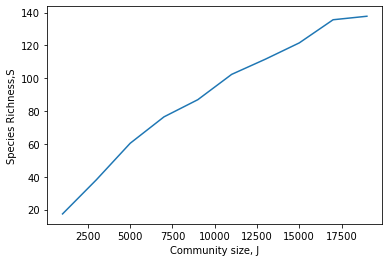

In [8]:
plt.plot(J_values,mr)
plt.ylabel('Species Richness,S')
plt.xlabel('Community size, J')

In [9]:
combination

(0.7395056279333407, 0.3578769233579647, 1.1606947753462955)

In [23]:
import pandas as pd

# Initialize an empty list to store the lengths of lists associated with each key
lengths_list = []

# Iterate through each dictionary
for d in rich:
    # Initialize a dictionary to store lengths for each key
    lengths_dict = {}
    
    # Iterate through the keys and their associated lists
    for key, value in d.items():
        lengths_dict[key] = len(value)
    
    # Append the lengths as a dictionary to the lengths_list
    lengths_list.append(lengths_dict)

# Create a DataFrame from the list of dictionaries
df = pd.DataFrame(lengths_list)

# Transpose the DataFrame
transposed_df = df.transpose()  # or df.T

# Display the transposed DataFrame
print(transposed_df)


        0    1    2    3    4    5    6    7    8    9
0     100  100  100  100  100  100  100  100  100  100
1     100  100  100  100  100  100  100  100  100  100
2      91   98   99  100  100  100  100  100  100  100
3      87   96   99   98  100  100  100   99  100  100
4      86   96   98   98  100  100  100   99  100  100
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...
1795   24   33   50   68   74  105  117  126  139  132
1796   21   35   49   68   73  105  115  123  142  134
1797   21   34   49   71   73  103  118  123  141  132
1798   22   34   47   70   75  106  118  122  140  132
1799   23   34   47   72   76  106  119  121  141  132

[1800 rows x 10 columns]


In [19]:
transposed_df.columns


RangeIndex(start=0, stop=10, step=1)

In [24]:
J_values = {'0': 'J_1000', '1':"J_3000", '2':'J_5000','3':"J_7000",'4':'J_9000','5':'J_11000','6':'J_13000','7':'J_15000','8':'J_17000','8':'J_19000'}  # Add more values as needed


In [22]:
df_J_values1

In [25]:
transposed_df.rename(columns=J_values, inplace =True)
#df_J_values1.to_excel("data_J_values_richness.xlsx",index=False)

In [31]:
transposed_df.columns=[J_values.get(col,col) for col in transposed_df.columns]
transposed_df.to_excel("data_J_values_richness1.xlsx",index=False)

In [9]:
J=[1000,3000,5000,8000,11000,13000,15000,20000]
Species_rich = []
Mean_rich = []
for i in J:
    Species_rich.append(J_values(i)[1])
    Mean_rich.append(J_values(i)[0])
    

Elapsed time: 0.9866971969604492 seconds
Elapsed time: 0.8498156070709229 seconds
Elapsed time: 0.7180643081665039 seconds
Elapsed time: 0.7964432239532471 seconds
Elapsed time: 0.8223674297332764 seconds
Elapsed time: 0.7821042537689209 seconds
Elapsed time: 0.7687060832977295 seconds
Elapsed time: 0.8831167221069336 seconds
Elapsed time: 0.7248597145080566 seconds
Elapsed time: 0.8252294063568115 seconds
Elapsed time: 0.7268979549407959 seconds
Elapsed time: 1.1980311870574951 seconds
Elapsed time: 0.7302379608154297 seconds
Elapsed time: 0.820235013961792 seconds
Elapsed time: 0.8151068687438965 seconds
Elapsed time: 0.8965182304382324 seconds


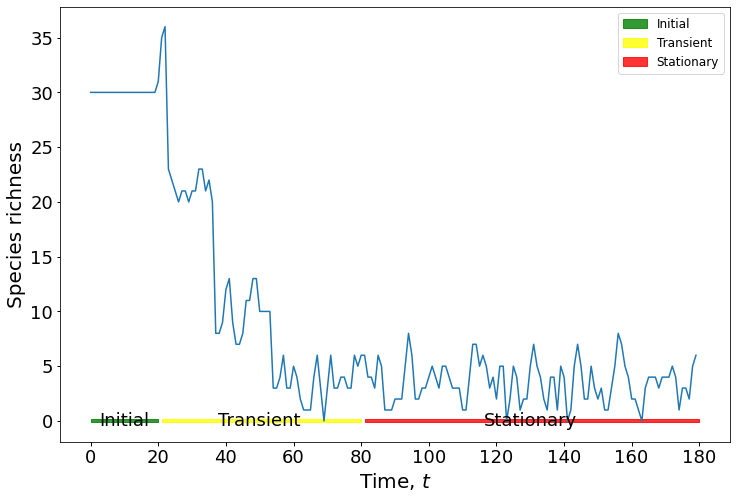

In [120]:
import matplotlib.pyplot as plt

# Assuming you have a DataFrame called fina_df

# Create a figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the data from the column
ax.plot(richness)

# Define the range boundaries
initial_range = (0, 20)
transient_range = (21, 80)
stationary_range = (81, 180)

# Shade the areas between the ranges
ax.fill_between(initial_range, -0.1, 0.2, color='green', alpha=0.8, label='Initial')
ax.fill_between(transient_range, -0.1, 0.2, color='yellow', alpha=0.8, label='Transient')
ax.fill_between(stationary_range, -0.1, 0.2, color='red', alpha=0.8, label='Stationary')

# Set x-axis ticks
ax.set_xticks(range(0, 180 + 1, 20))

# Set labels for x-axis and y-axis
ax.set_xlabel('Time, $t$', fontsize=20)
ax.set_ylabel('Species richness', fontsize=20)

# Add legend
ax.legend(fontsize=12)

# Increase the font size of the tick labels
ax.tick_params(axis='both', labelsize=18)

# Bolden the tick labels
ax.xaxis.set_tick_params(which='both', width=1)
ax.yaxis.set_tick_params(which='both', width=1)

# Add text labels for the ranges
ax.text(10, 0.0, 'Initial', rotation=0, va='center', ha='center', fontsize=18)
ax.text(50, 0.0, 'Transient', rotation=0, va='center', ha='center', fontsize=18)
ax.text(130, 0.0, 'Stationary', rotation=0, va='center', ha='center', fontsize=18)

# Save the plot as a PNG image
plt.savefig('local_com.png', dpi=900)


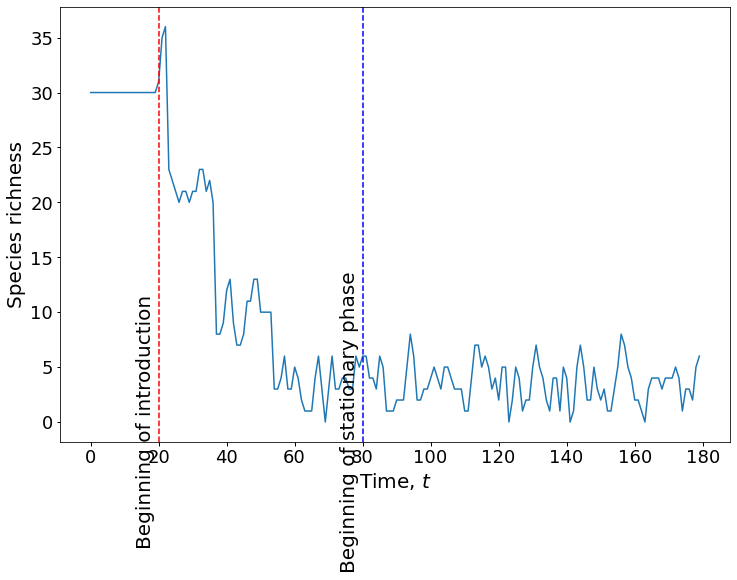

In [115]:
import matplotlib.pyplot as plt

# Assuming you have a DataFrame called fina_df

# Create a figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Add text along a vertical line
vertical_x = 20
vertical_text = 'Beginning of introduction'

# Plot the data from the column
ax.plot(richness)

# Add vertical lines at values 200 and 800
ax.axvline(x=20, color='red', linestyle='--')
ax.axvline(x=80, color='blue', linestyle='--')

# Set x-axis ticks
ax.set_xticks(range(0, 180 + 1, 20))

# Set labels for x-axis and y-axis
ax.set_xlabel('Time, $t$', fontsize=20)
ax.set_ylabel('Species richness', fontsize=20)

# Add text labels
ax.text(19, 0, vertical_text, rotation=90, va='center', ha='right', fontsize=20)
ax.text(79, 0, 'Beginning of stationary phase', rotation=90, va='center', ha='right', fontsize=20)

# Increase the font size of the tick labels
#ax.tick_params(axis='both', labelsize=20)
# Increase the font size of the tick labels
ax.tick_params(axis='both', labelsize=18)

# Bolden the tick labels
ax.xaxis.set_tick_params(which='both', width=1)
ax.yaxis.set_tick_params(which='both', width=1)

# Save the plot as a PNG image
plt.savefig('local_com.png', dpi=900)

# Show the plot
plt.show()


In [38]:
final_df.to_excel('dynamics_sample2_data.xlsx', index=False)

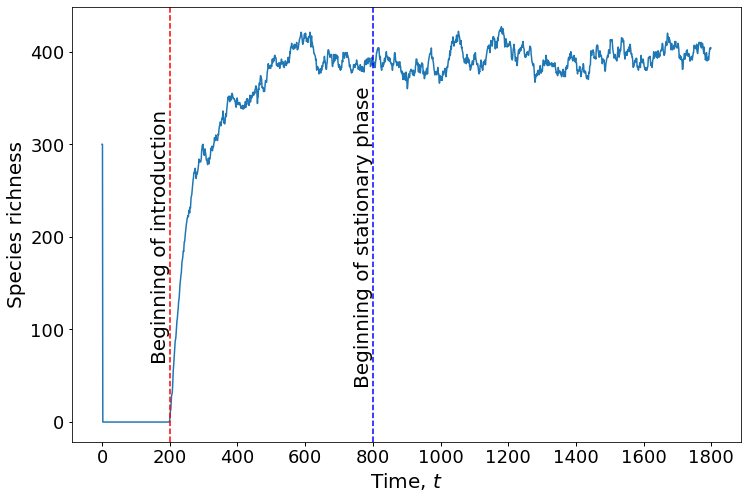

In [42]:
import matplotlib.pyplot as plt

# Assuming you have a DataFrame called fina_df

# Create a figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Add text along a vertical line
vertical_x = 200
vertical_text = 'Beginning of introduction'

# Plot the data from the column
ax.plot(final_df['Richness_0'])

# Add vertical lines at values 200 and 800
ax.axvline(x=20, color='red', linestyle='--')
ax.axvline(x=80, color='blue', linestyle='--')

# Set x-axis ticks
ax.set_xticks(range(0, 180 + 1, 200))

# Set labels for x-axis and y-axis
ax.set_xlabel('Time, $t$', fontsize=20)
ax.set_ylabel('Species richness', fontsize=20)

# Add text labels
ax.text(vertical_x, 19, vertical_text, rotation=90, va='center', ha='right', fontsize=20)
ax.text(179, 200, 'Beginning of stationary phase', rotation=90, va='center', ha='right', fontsize=20)

# Increase the font size of the tick labels
#ax.tick_params(axis='both', labelsize=20)
# Increase the font size of the tick labels
ax.tick_params(axis='both', labelsize=18)

# Bolden the tick labels
ax.xaxis.set_tick_params(which='both', width=1)
ax.yaxis.set_tick_params(which='both', width=1)

# Save the plot as a PNG image
plt.savefig('local_com.png', dpi=900)

# Show the plot
plt.show()


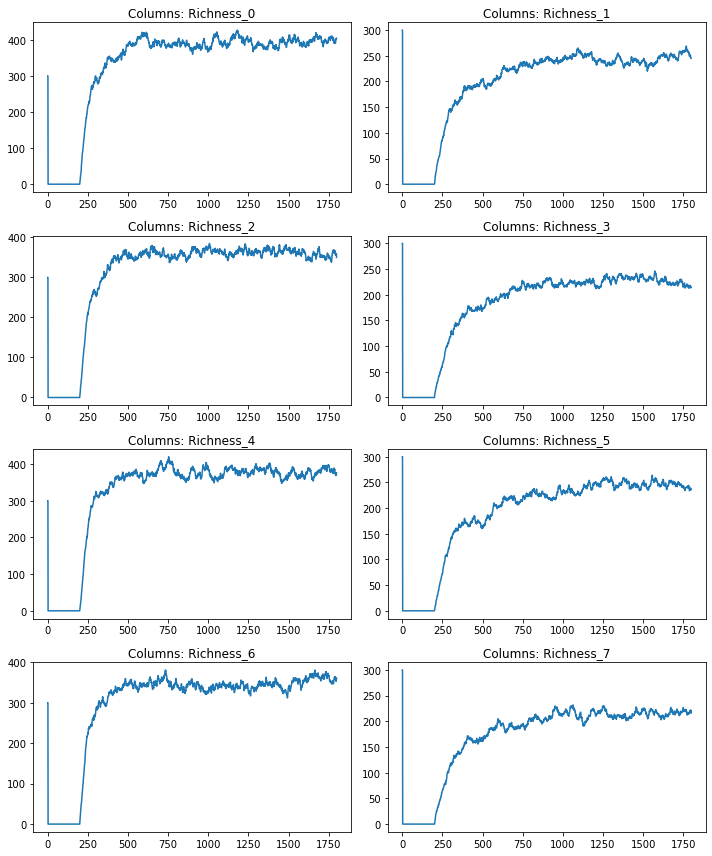

In [32]:
import matplotlib.pyplot as plt

# Assuming you have two DataFrames: df1 and df2

# Create a figure with subplots
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(10, 12))

# Iterate over the subplot positions
for i, ax in enumerate(axs.flat):
    # Get the column pair indices
    col_index = i % len(final_df.columns)
    row_index = i // len(final_df.columns)

    # Get the column names
    column1 = final_df.columns[col_index]
    #column2 = final_df.columns[col_index]

    # Plot the data from df1 and df2 in the corresponding subplot
    ax.plot(final_df[column1])

    # Set subplot title
    ax.set_title(f'Columns: {column1}')

# Adjust the layout of subplots
plt.tight_layout()

# Show the plot
plt.show()


In [33]:
ax.xaxis.set_tick_params?

JupyterRequireError: buttons.colvis: Timeout. Library 'buttons.colvis' is not loaded.

JupyterRequireError: notebook/js/codecell: Timeout. Library 'notebook/js/codecell' is not loaded.

JupyterRequireError: buttons.colvis: Timeout. Library 'buttons.colvis' is not loaded.